In [38]:
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn
!pip install joblib
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import sys
import seaborn as sns
import time
import joblib

In [2]:
path = r"BandraKurlaComplexMumbaiIITM.csv"

df = pd.read_csv(path)

In [9]:

df.head(1)



,Unnamed: 0,From Date,To Date,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,...,MP-Xylene,RH,WS,WD,SR,BP,Xylene,AT,RF,TOT-RF
0,0,2021-01-01 00:00:00,2021-01-01 00:15:00,147.26,175.93,16.23,61.72,45.3,79.76,4.68,...,NaN,94.14,0.46,187.53,NaN,953.2,0.0,21.84,0.0,0.0


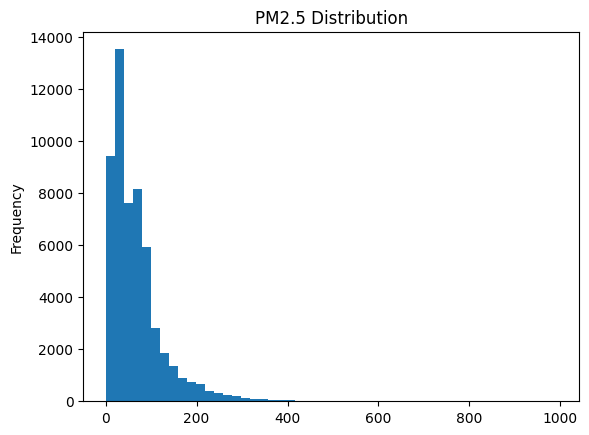

In [10]:
df["PM2.5"].plot(kind="hist", bins=50)
plt.title("PM2.5 Distribution")
plt.show()

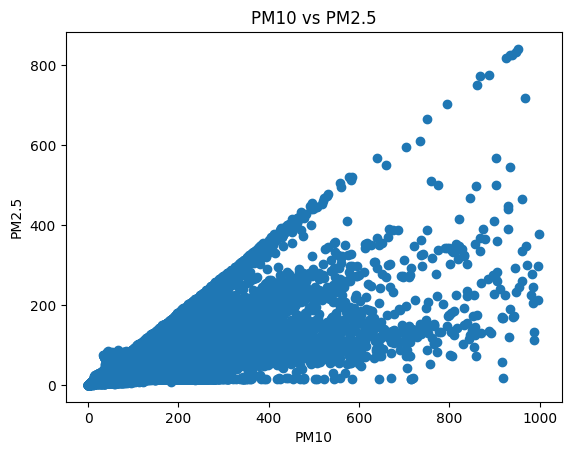

In [11]:
plt.scatter(df["PM10"],df["PM2.5"])
plt.xlabel("PM10")
plt.ylabel("PM2.5")
plt.title("PM10 vs PM2.5")
plt.show()

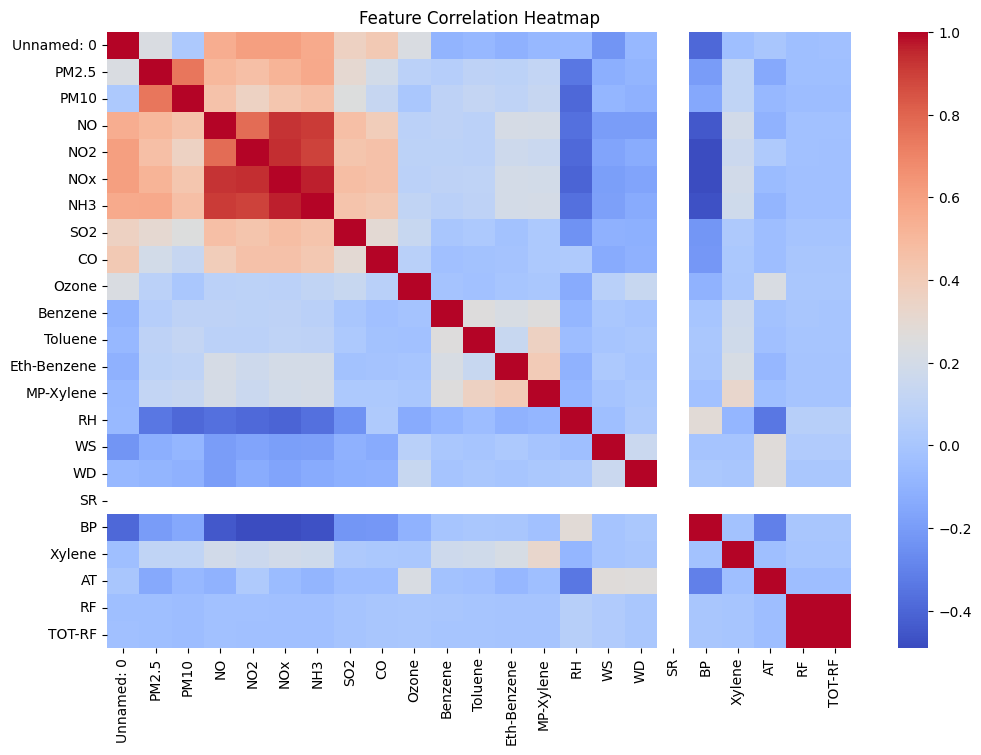

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
df.corr(numeric_only=True)["PM2.5"].sort_values(ascending=False)

PM2.5          1.000000
PM10           0.744472
NH3            0.567426
NOx            0.519344
NO             0.505108
NO2            0.468973
SO2            0.305935
Unnamed: 0     0.233474
CO             0.194000
MP-Xylene      0.120525
Xylene         0.105663
Toluene        0.095421
Eth-Benzene    0.090016
Ozone          0.083558
Benzene        0.061541
RF            -0.040836
TOT-RF        -0.041371
WD            -0.088593
WS            -0.121753
AT            -0.143488
BP            -0.204951
RH            -0.342155
SR                  NaN
Name: PM2.5, dtype: float64

In [14]:
df.isnull().sum()

Unnamed: 0         0
From Date          0
To Date            0
PM2.5          21769
PM10           22060
NO             24876
NO2            24336
NOx            24236
NH3            24698
SO2            24429
CO             21873
Ozone          22107
Benzene        19965
Toluene        20050
Eth-Benzene    22646
MP-Xylene      23564
RH             20197
WS             20521
WD             20391
SR             76475
BP             20139
Xylene         20058
AT             33700
RF             20106
TOT-RF             0
dtype: int64

In [15]:
len(df)

76475

In [16]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

SR             100.000000
AT              44.066688
NO              32.528277
NH3             32.295521
SO2             31.943772
NO2             31.822164
NOx             31.691402
MP-Xylene       30.812684
Eth-Benzene     29.612292
Ozone           28.907486
PM10            28.846028
CO              28.601504
PM2.5           28.465512
WS              26.833606
WD              26.663616
RH              26.409938
BP              26.334096
RF              26.290945
Xylene          26.228179
Toluene         26.217718
Benzene         26.106571
To Date          0.000000
From Date        0.000000
Unnamed: 0       0.000000
TOT-RF           0.000000
dtype: float64


In [17]:
df.drop(columns=["SR","RF","TOT-RF"])

,Unnamed: 0,From Date,To Date,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,...,Benzene,Toluene,Eth-Benzene,MP-Xylene,RH,WS,WD,BP,Xylene,AT
0,0,2021-01-01 00:00:00,2021-01-01 00:15:00,147.26,175.93,16.23,61.72,45.30,79.76,4.68,...,0.00,0.00,NaN,NaN,94.14,0.46,187.53,953.2,0.00,21.84
1,1,2021-01-01 00:15:00,2021-01-01 00:30:00,145.37,173.96,16.88,61.50,45.75,79.01,18.49,...,0.00,0.00,NaN,NaN,94.99,0.47,224.11,953.2,0.00,21.84
2,2,2021-01-01 00:30:00,2021-01-01 00:45:00,156.71,186.12,22.71,62.99,51.15,84.96,17.62,...,0.00,0.00,NaN,NaN,93.88,0.46,212.47,953.2,0.00,22.01
3,3,2021-01-01 00:45:00,2021-01-01 01:00:00,171.18,205.41,16.55,59.13,44.19,77.83,18.14,...,0.00,0.00,NaN,NaN,93.38,0.27,216.65,954.2,0.00,21.99
4,4,2021-01-01 01:00:00,2021-01-01 01:15:00,183.17,219.31,20.39,59.87,47.66,81.63,18.69,...,0.00,0.00,NaN,NaN,92.44,0.17,103.12,954.9,0.00,22.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76470,76470,2023-08-03 13:30:00,2023-08-03 13:45:00,89.07,187.55,128.94,107.15,163.90,173.35,50.83,...,6.34,18.19,8.73,8.75,NaN,NaN,NaN,NaN,8.12,NaN
76471,76471,2023-08-03 13:45:00,2023-08-03 14:00:00,93.35,177.91,96.45,105.15,128.26,148.24,43.74,...,6.30,18.88,8.72,8.47,NaN,NaN,NaN,NaN,10.09,NaN
76472,76472,2023-08-03 14:00:00,2023-08-03 14:15:00,95.64,177.82,118.26,158.14,177.40,179.00,40.37,...,6.30,19.24,7.38,9.36,NaN,NaN,NaN,NaN,9.32,NaN
76473,76473,2023-08-03 14:15:00,2023-08-03 14:30:00,101.09,175.04,105.69,149.00,163.99,155.00,40.38,...,6.29,20.12,8.27,9.55,NaN,NaN,NaN,NaN,9.27,NaN


In [18]:
df = df.fillna(method="ffill").fillna(df.median(numeric_only=True))

C:\Users\RVAISH\AppData\Local\Temp\ipykernel_33912\1337798703.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill").fillna(df.median(numeric_only=True))


In [19]:
df

,Unnamed: 0,From Date,To Date,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,...,MP-Xylene,RH,WS,WD,SR,BP,Xylene,AT,RF,TOT-RF
0,0,2021-01-01 00:00:00,2021-01-01 00:15:00,147.26,175.93,16.23,61.72,45.30,79.76,4.68,...,4.01,94.14,0.46,187.53,NaN,953.2,0.00,21.84,0.0,0.0
1,1,2021-01-01 00:15:00,2021-01-01 00:30:00,145.37,173.96,16.88,61.50,45.75,79.01,18.49,...,4.01,94.99,0.47,224.11,NaN,953.2,0.00,21.84,0.0,0.0
2,2,2021-01-01 00:30:00,2021-01-01 00:45:00,156.71,186.12,22.71,62.99,51.15,84.96,17.62,...,4.01,93.88,0.46,212.47,NaN,953.2,0.00,22.01,0.0,0.0
3,3,2021-01-01 00:45:00,2021-01-01 01:00:00,171.18,205.41,16.55,59.13,44.19,77.83,18.14,...,4.01,93.38,0.27,216.65,NaN,954.2,0.00,21.99,0.0,0.0
4,4,2021-01-01 01:00:00,2021-01-01 01:15:00,183.17,219.31,20.39,59.87,47.66,81.63,18.69,...,4.01,92.44,0.17,103.12,NaN,954.9,0.00,22.04,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76470,76470,2023-08-03 13:30:00,2023-08-03 13:45:00,89.07,187.55,128.94,107.15,163.90,173.35,50.83,...,8.75,86.42,0.44,147.12,NaN,950.0,8.12,15.55,0.0,0.0
76471,76471,2023-08-03 13:45:00,2023-08-03 14:00:00,93.35,177.91,96.45,105.15,128.26,148.24,43.74,...,8.47,86.42,0.44,147.12,NaN,950.0,10.09,15.55,0.0,0.0
76472,76472,2023-08-03 14:00:00,2023-08-03 14:15:00,95.64,177.82,118.26,158.14,177.40,179.00,40.37,...,9.36,86.42,0.44,147.12,NaN,950.0,9.32,15.55,0.0,0.0
76473,76473,2023-08-03 14:15:00,2023-08-03 14:30:00,101.09,175.04,105.69,149.00,163.99,155.00,40.38,...,9.55,86.42,0.44,147.12,NaN,950.0,9.27,15.55,0.0,0.0


In [24]:
X = df.drop(columns=["Unnamed: 0","From Date","To Date","SR","RF","TOT-RF","PM2.5"])

In [25]:
y = df["PM2.5"]

In [26]:
X_train,X_test,y_train,y_test = sk.model_selection.train_test_split(X,y,test_size = 0.2, random_state = 42)

In [17]:
scaler = sk.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Depth: 1 R2: 0.3251109393145014
Depth: 2 R2: 0.4840217665784635
Depth: 3 R2: 0.57129757706932
Depth: 4 R2: 0.6445532748093881
Depth: 5 R2: 0.6859406319095437
Depth: 6 R2: 0.6993665559153135
Depth: 7 R2: 0.7253718624409878
Depth: 8 R2: 0.7614655828170456
Depth: 9 R2: 0.7645523128591499
Depth: 10 R2: 0.7664794396536256
Depth: 11 R2: 0.8008937244159219
Depth: 12 R2: 0.7785659904237878
Depth: 13 R2: 0.7748815966138293
Depth: 14 R2: 0.7780641677872113
Depth: 15 R2: 0.784927359514503
Depth: 16 R2: 0.7662471894314082
Depth: 17 R2: 0.7920569139732567
Depth: 18 R2: 0.7807096551324726
Depth: 19 R2: 0.7692590316356716
Depth: 20 R2: 0.7873154428698643
Depth: 21 R2: 0.7886710049507006
Depth: 22 R2: 0.787024064751596
Depth: 23 R2: 0.7765795451836016
Depth: 24 R2: 0.7757277042207242
Depth: 25 R2: 0.7794543747628216
Depth: 26 R2: 0.7716303738625995
Depth: 27 R2: 0.7687220933148768
Depth: 28 R2: 0.7828987873489506
Depth: 29 R2: 0.7904446511092191
Depth: 30 R2: 0.7669205172051006


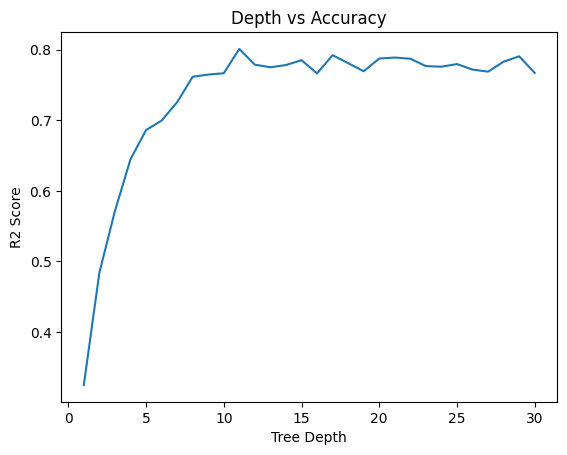

In [18]:
#looping to check best for DT

depths = range(1, 31)

results = []

for d in depths:
    model = sk.tree.DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    r2 = sk.metrics.r2_score(y_test, pred)
    
    results.append((d, r2))

for r in results:
    print("Depth:", r[0], "R2:", r[1])

depths_list = [r[0] for r in results]
r2_list = [r[1] for r in results]

plt.plot(depths_list, r2_list)
plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.title("Depth vs Accuracy")
plt.show()

In [21]:
#the svm model
start = time.time()
model_svm = sk.svm.SVR(kernel = "rbf")
model_svm.fit(X_train_scaled,y_train)
end = time.time()

svm_time = end-start

#the random forest model
start = time.time()
model_rf = sk.ensemble.RandomForestRegressor()
model_rf.fit(X_train,y_train)
end = time.time()

rf_time = end - start

#shows what is important int he rf model
imp = pd.Series(model_rf.feature_importances_, index = X.columns)
print(imp.sort_values(ascending=False))

#the decision tree model
start = time.time()
model_dt = sk.tree.DecisionTreeRegressor(max_depth=11, random_state=42)
model_dt.fit(X_train,y_train)
end = time.time()

dt_time = end-start

print("Time taken by SVM:",svm_time)
print("Time taken by RF:",rf_time)
print("Time taken by DT:",dt_time)

PM10           0.579911
NH3            0.149357
NO2            0.028851
Benzene        0.026623
RH             0.023373
Ozone          0.021622
CO             0.021364
AT             0.019650
Toluene        0.019179
NOx            0.015610
WD             0.015240
Xylene         0.014741
SO2            0.013777
BP             0.012875
NO             0.011754
MP-Xylene      0.009452
Eth-Benzene    0.008636
WS             0.007986
dtype: float64
Time taken by SVM: 108.98968243598938
Time taken by RF: 68.61257934570312
Time taken by DT: 0.5707118511199951


In [22]:
pred_svm = model_svm.predict(X_test_scaled)
pred_rf = model_rf.predict(X_test)
pred_dt = model_dt.predict(X_test)

r2_svm = sk.metrics.r2_score(y_test,pred_svm)
r2_rf = sk.metrics.r2_score(y_test,pred_rf)
r2_dt = sk.metrics.r2_score(y_test,pred_dt)

mse_svm = sk.metrics.mean_squared_error(y_test,pred_svm)
mse_rf =  sk.metrics.mean_squared_error(y_test,pred_rf)
mse_dt =  sk.metrics.mean_squared_error(y_test,pred_dt)

rmse_svm = np.sqrt(mse_svm)
rmse_rf = np.sqrt(mse_rf)
rmse_dt = np.sqrt(mse_dt)

print("R2 SVM:", r2_svm)
print("R2 RF:", r2_rf)
print("R2 DT:", r2_dt)
print("MSE SVM:", mse_svm)
print("MSE RF:", mse_rf)
print("MSE DT:", mse_dt)
print("RMSE SVM:", rmse_svm)
print("RMSE RF:", rmse_rf)
print("RMSE DT:", rmse_dt)

R2 SVM: 0.5894811244076276
R2 RF: 0.8963464757755205
R2 DT: 0.8008937244159219
MSE SVM: 1802.8130621921819
MSE RF: 455.19935507106175
MSE DT: 874.3846281597915
RMSE SVM: 42.45954618448226
RMSE RF: 21.335401450899905
RMSE DT: 29.56999540344556


In [23]:
#Found Random FOrests to be the best even without tuning, tunin git now
param_grid = {
    'n_estimators': [50,100, 200,300],
    'max_depth': [5,10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = sk.ensemble.RandomForestRegressor(random_state=42)

grid = sk.model_selection.GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best score: 0.8786763177630385


In [24]:
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score

print(r2_score(y_test, pred))

0.896700378261162


In [26]:
imp = pd.Series(best_rf.feature_importances_,index = X_train.columns).sort_values(ascending = False)
print(imp)

PM10           0.580216
NH3            0.151003
NO2            0.029159
Benzene        0.025600
RH             0.023629
CO             0.020932
Toluene        0.020833
Ozone          0.020262
AT             0.020089
WD             0.015272
NOx            0.015266
Xylene         0.014174
SO2            0.013852
BP             0.012262
NO             0.012105
Eth-Benzene    0.008925
MP-Xylene      0.008881
WS             0.007542
dtype: float64


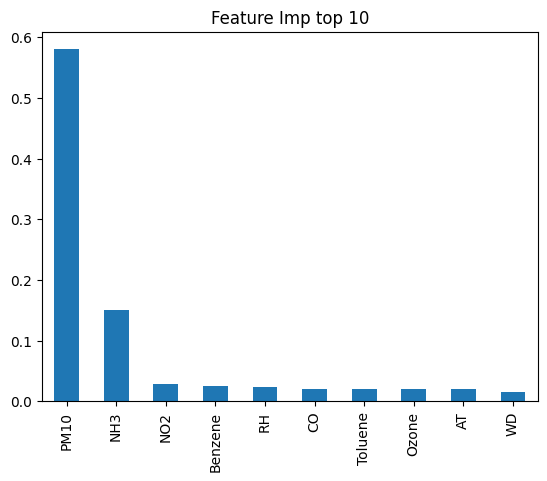

In [27]:
imp.head(10).plot(kind="bar")
plt.title("Feature Imp top 10")
plt.show()

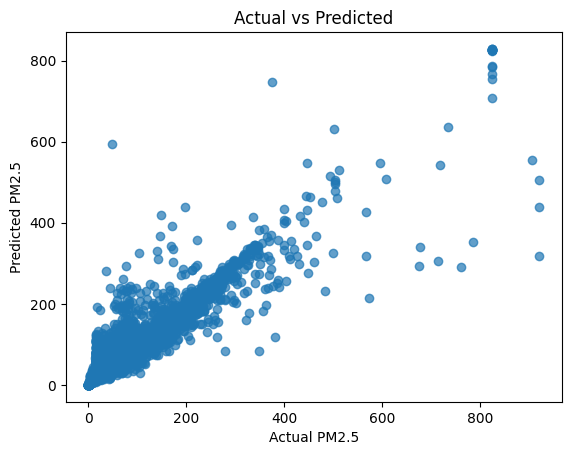

In [33]:
pred = best_rf.predict(X_test)

plt.scatter(y_test,pred,alpha = 0.7)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")
plt.show()

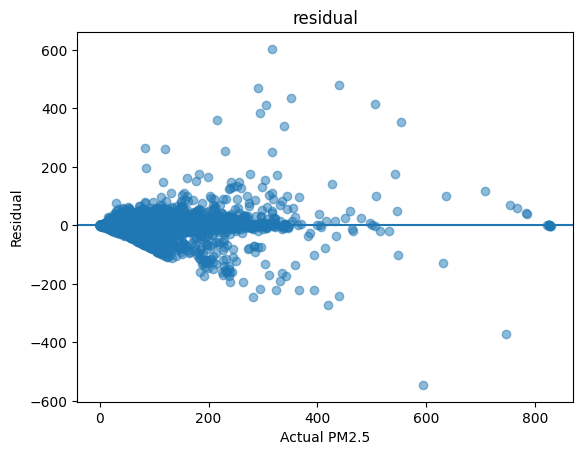

In [34]:
residuals = y_test - pred

plt.scatter(pred,residuals,alpha = 0.5)
plt.axhline(0)
plt.xlabel("Actual PM2.5")
plt.ylabel("Residual")
plt.title("residual")
plt.show()

In [37]:
joblib.dump(best_rf,"rf_model.pkl")

['rf_model.pkl']

In [20]:
pd.set_option('display.max_columns', None)
df.head(1)



,Unnamed: 0,From Date,To Date,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,Toluene,Eth-Benzene,MP-Xylene,RH,WS,WD,SR,BP,Xylene,AT,RF,TOT-RF
0,0,2021-01-01 00:00:00,2021-01-01 00:15:00,147.26,175.93,16.23,61.72,45.3,79.76,4.68,1.38,13.0,0.0,0.0,3.0,4.01,94.14,0.46,187.53,NaN,953.2,0.0,21.84,0.0,0.0


In [30]:
small_rf = sk.ensemble.RandomForestRegressor(
    n_estimators=120,        
    max_depth=15,            
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

small_rf.fit(X_train, y_train)
pred = small_rf.predict(X_test)

print("R2:", sk.metrics.r2_score(y_test, pred))

R2: 0.8628507533675779


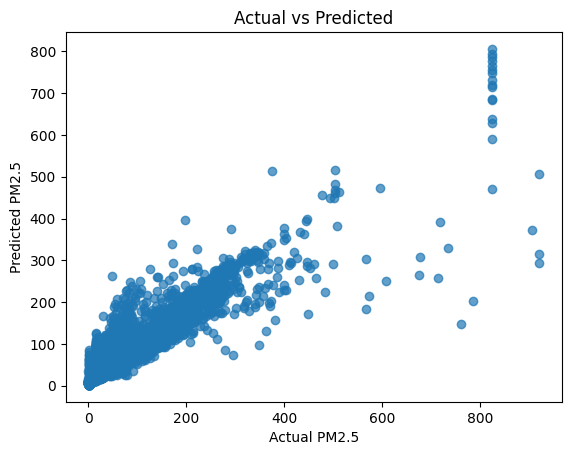

In [32]:
plt.scatter(y_test,pred,alpha = 0.7)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")
plt.show()

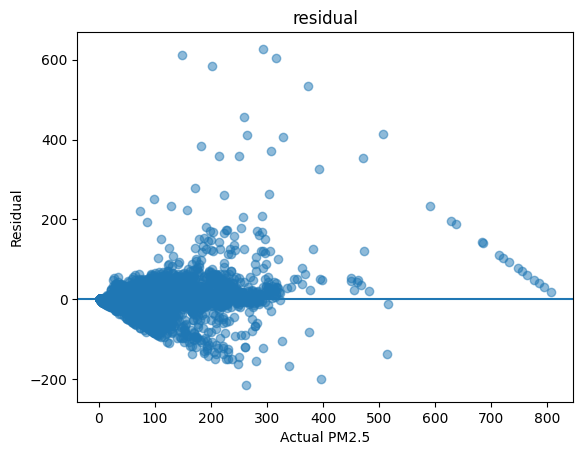

In [33]:
residuals = y_test - pred

plt.scatter(pred,residuals,alpha = 0.5)
plt.axhline(0)
plt.xlabel("Actual PM2.5")
plt.ylabel("Residual")
plt.title("residual")
plt.show()

In [35]:
joblib.dump(small_rf,"rf_model.pkl")

['rf_model.pkl']